# Анализ потребления электроэнергии по дням и годам

Ноутбук объединяет логику утилит проекта:
- `ChartByDay` — загрузка/парсинг данных, дневные метрики, графики и тренд;
- `AnalysisYear` — годовой/сезонный анализ;
- `project_tree` — печать дерева проекта.

Запускать из папки `project/notebooks`.


## 1. Импорты и настройки

In [1]:
import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Настройки графиков
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10


## 2. Дерево проекта (по мотивам `project_tree.py`)

In [2]:
def print_tree(directory: Path, prefix: str = "", ignore: set = None,
               max_depth: int = None, current_depth: int = 0):
    if ignore is None:
        ignore = {
            ".git", "__pycache__", ".venv", "venv", "env",
            "node_modules", ".idea", ".vscode", ".mypy_cache",
            ".pytest_cache", "dist", "build", ".eggs", "*.egg-info",
        }
    if max_depth is not None and current_depth > max_depth:
        return
    try:
        entries = sorted(directory.iterdir(), key=lambda e: (e.is_file(), e.name.lower()))
    except PermissionError:
        print(prefix + "  [Нет доступа]")
        return
    entries = [e for e in entries if e.name not in ignore and not e.name.endswith(".egg-info")]
    for i, entry in enumerate(entries):
        is_last = i == len(entries) - 1
        connector = "\u2514\u2500\u2500 " if is_last else "\u251c\u2500\u2500 "
        icon = "\U0001F4C1 " if entry.is_dir() else "\U0001F4C4 "
        print(prefix + connector + icon + entry.name)
        if entry.is_dir():
            extension = "    " if is_last else "\u2502   "
            print_tree(entry, prefix + extension, ignore, max_depth, current_depth + 1)


def count_items(directory: Path, ignore: set = None):
    if ignore is None:
        ignore = {
            ".git", "__pycache__", ".venv", "venv", "env",
            "node_modules", ".idea", ".vscode", ".mypy_cache",
            ".pytest_cache", "dist", "build",
        }
    files = dirs = 0
    for entry in directory.rglob("*"):
        if any(part in ignore for part in entry.parts):
            continue
        if entry.is_file():
            files += 1
        elif entry.is_dir():
            dirs += 1
    return files, dirs


root = Path("..").resolve()
print(f"\n\U0001F4E6 \u041f\u0440\u043e\u0435\u043a\u0442: {root}\n")
print_tree(root, max_depth=2)
tf, td = count_items(root)
print(f"\n{'\u2500' * 40}")
print(f"\U0001F4C1 \u041f\u0430\u043f\u043e\u043a: {td}   \U0001F4C4 \u0424\u0430\u0439\u043b\u043e\u0432: {tf}")



📦 Проект: C:\Users\Дмитрий\PycharmProjects\regression_modeling\project

├── 📁 configs
│   ├── 📄 .env.example
│   └── 📄 s_config.json
├── 📁 data
│   ├── 📄 .gitkeep
│   ├── 📄 dataset.xlsx
│   └── 📄 dataset_no_intercept.xlsx
├── 📁 notebooks
│   ├── 📄 .gitkeep
│   ├── 📄 AnalysisYearByDay.ipynb
│   └── 📄 two_models_comparison.ipynb
├── 📁 src
│   ├── 📁 avto_test_py
│   │   ├── 📄 .gitkeep
│   │   ├── 📄 __init__.py
│   │   ├── 📄 benchmark_device.py
│   │   ├── 📄 run_specialists_gpu.py
│   │   ├── 📄 tune_allday_gpu.py
│   │   ├── 📄 tune_nonworkday_gpu.py
│   │   └── 📄 tune_workday_gpu.py
│   ├── 📁 utils
│   │   └── 📄 .gitkeep
│   ├── 📁 web_interface
│   │   ├── 📁 static
│   │   ├── 📁 templates
│   │   ├── 📄 __init__.py
│   │   └── 📄 app.py
│   └── 📄 run_webui.py
├── 📁 tests
│   ├── 📄 .gitkeep
│   └── 📄 test-34.py
├── 📄 docker-compose.yml
├── 📄 Dockerfile
├── 📄 project_overview.md
├── 📄 README.md
├── 📄 report.md
├── 📄 requirements.txt
└── 📄 self-checklist.md

───────────────────────────────────

## 3. Класс `ChartByDay` (по мотивам `ChartByDay.py`)

In [3]:
class ChartByDay:
    """Рисует подневные графики потребления на несколько лет."""

    @staticmethod
    def load_and_parse_data(filepath):
        """Загружает данные из CSV или Excel, автоопределяя тип по расширению."""
        if filepath.endswith('.xlsx') or filepath.endswith('.xls'):
            df = pd.read_excel(filepath, parse_dates=['dateByOurs'])
        elif filepath.endswith('.csv'):
            encodings = ['utf-8', 'cp1251', 'latin1']
            for enc in encodings:
                try:
                    df = pd.read_csv(filepath, decimal=',',
                                     parse_dates=['dateByOurs'], encoding=enc)
                    break
                except UnicodeDecodeError:
                    continue
            else:
                raise ValueError("\u041d\u0435 \u0443\u0434\u0430\u043b\u043e\u0441\u044c \u043f\u0440\u043e\u0447\u0438\u0442\u0430\u0442\u044c CSV")
        else:
            raise ValueError("\u041d\u0435\u043f\u043e\u0434\u0434\u0435\u0440\u0436\u0438\u0432\u0430\u0435\u043c\u044b\u0439 \u0444\u043e\u0440\u043c\u0430\u0442 \u0444\u0430\u0439\u043b\u0430. \u0418\u0441\u043f\u043e\u043b\u044c\u0437\u0443\u0439\u0442\u0435 .csv \u0438\u043b\u0438 .xlsx")
        if df['dateByOurs'].dtype == 'object':
            raise ValueError("\u041d\u0435 \u0443\u0434\u0430\u043b\u043e\u0441\u044c \u0440\u0430\u0441\u043f\u0430\u0440\u0441\u0438\u0442\u044c 'dateByOurs' \u043a\u0430\u043a \u0434\u0430\u0442\u0443")
        return df

    @staticmethod
    def filter_by_period(df, start_date=None, end_date=None):
        """Фильтрует датасет по временному интервалу."""
        df = df.copy()
        if start_date:
            if isinstance(start_date, str):
                start_date = datetime.strptime(start_date, '%Y-%m-%d')
            df = df[df['dateByOurs'] >= start_date]
        if end_date:
            if isinstance(end_date, str):
                end_date = datetime.strptime(end_date, '%Y-%m-%d')
            df = df[df['dateByOurs'] <= end_date]
        return df

    @staticmethod
    def calculate_daily_metrics(df):
        """Группирует почасовые данные по дням."""
        df = df.copy()
        df['date_only'] = df['dateByOurs'].dt.date
        daily_stats = df.groupby('date_only').agg(
            total_consumption=('Ypowerconsumption', 'sum'),
            avg_consumption=('Ypowerconsumption', 'mean'),
            hour_count=('Ypowerconsumption', 'count')
        ).reset_index()
        daily_stats['is_complete'] = daily_stats['hour_count'] == 24
        return daily_stats

    @staticmethod
    def add_trend_line(ax, x_data, y_data, color='red'):
        """Добавляет линию линейного тренда."""
        x_numeric = mdates.date2num(x_data)
        coefficients = np.polyfit(x_numeric, y_data, deg=1)
        polynomial = np.poly1d(coefficients)
        trend_line = polynomial(x_numeric)
        ax.plot(x_data, trend_line, color=color, linewidth=2,
                label='\u0422\u0440\u0435\u043d\u0434 (\u043b\u0438\u043d\u0435\u0439\u043d\u0430\u044f \u0440\u0435\u0433\u0440\u0435\u0441\u0441\u0438\u044f)', zorder=5)
        k, b = coefficients
        return f'y = {k*365:.2f}x + {b:.2f} (\u043a\u043e\u044d\u0444. \u0432 \u0433\u043e\u0434)'

    @staticmethod
    def plot_daily_consumption(daily_df, metric='total_consumption',
                               title=None, filename=None,
                               add_regression=True, figsize_width=20):
        """Строит и сохраняет график дневного потребления."""
        daily_df = daily_df.sort_values('date_only')
        x = daily_df['date_only']
        y = daily_df[metric]
        if metric == 'total_consumption':
            ylabel = '\u041f\u043e\u0442\u0440\u0435\u0431\u043b\u0435\u043d\u0438\u0435 \u0437\u0430 \u0434\u0435\u043d\u044c (\u043a\u0412\u0442\u00b7\u0447)'
            default_title = '\u0414\u0438\u043d\u0430\u043c\u0438\u043a\u0430 \u0421\u0423\u041c\u041c\u0410\u0420\u041d\u041e\u0413\u041e \u0434\u043d\u0435\u0432\u043d\u043e\u0433\u043e \u043f\u043e\u0442\u0440\u0435\u0431\u043b\u0435\u043d\u0438\u044f'
        else:
            ylabel = '\u0421\u0440\u0435\u0434\u043d\u0435\u0435 \u043f\u043e\u0447\u0430\u0441\u043e\u0432\u043e\u0435 \u043f\u043e\u0442\u0440\u0435\u0431\u043b\u0435\u043d\u0438\u0435 (\u043a\u0412\u0442)'
            default_title = '\u0414\u0438\u043d\u0430\u043c\u0438\u043a\u0430 \u0421\u0420\u0415\u0414\u041d\u0415\u0413\u041e \u043f\u043e\u0447\u0430\u0441\u043e\u0432\u043e\u0433\u043e \u043f\u043e\u0442\u0440\u0435\u0431\u043b\u0435\u043d\u0438\u044f'
        title = title or default_title
        fig, ax = plt.subplots(figsize=(figsize_width, 6))
        ax.plot(x, y, linewidth=0.8, color='steelblue', alpha=0.7, label='\u0424\u0430\u043a\u0442\u0438\u0447\u0435\u0441\u043a\u0438\u0435 \u0434\u0430\u043d\u043d\u044b\u0435')
        if add_regression:
            trend_eq = ChartByDay.add_trend_line(ax, x, y)
            ax.text(0.02, 0.98, trend_eq, transform=ax.transAxes, fontsize=9,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
                    fontfamily='monospace')
        ax.set_xlabel('\u0414\u0430\u0442\u0430', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=14, pad=20)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='best', fontsize=9)
        if filename:
            os.makedirs(os.path.dirname(filename), exist_ok=True)
            plt.savefig(filename, format='png', dpi=300,
                        bbox_inches='tight', pad_inches=0.1, facecolor='white')
            print(f"\u2705 \u0413\u0440\u0430\u0444\u0438\u043a \u0441\u043e\u0445\u0440\u0430\u043d\u0451\u043d: {filename}")
        plt.tight_layout()
        plt.show()
        return fig, ax


## 4. Загрузка данных (по мотивам `AnalysisYear.py`)

In [4]:
filepath = '../data/dataset_no_intercept.xlsx'  # \u0444\u0430\u0439\u043b \u0432 \u043f\u0430\u043f\u043a\u0435 data

try:
    df = ChartByDay.load_and_parse_data(filepath)
    print(f"\U0001F4CA \u0417\u0430\u0433\u0440\u0443\u0436\u0435\u043d\u043e \u0437\u0430\u043f\u0438\u0441\u0435\u0439: {len(df)}")
    print(f"\U0001F4C5 \u041f\u0435\u0440\u0438\u043e\u0434: {df['dateByOurs'].min()} \u2014 {df['dateByOurs'].max()}")
except FileNotFoundError:
    print(f"\u274c \u0424\u0430\u0439\u043b {filepath} \u043d\u0435 \u043d\u0430\u0439\u0434\u0435\u043d. \u0413\u0435\u043d\u0435\u0440\u0438\u0440\u0443\u044e \u0434\u0435\u043c\u043e-\u0434\u0430\u043d\u043d\u044b\u0435.")
    dates = pd.date_range('2019-01-01', periods=24*365*4, freq='h')
    trend = np.linspace(200, 220, len(dates))
    seasonality = 30 * np.sin(2 * np.pi * np.arange(len(dates)) / (24*365))
    noise = np.random.normal(0, 15, len(dates))
    df = pd.DataFrame({'dateByOurs': dates,
                       'Ypowerconsumption': trend + seasonality + noise})

df.head()


📊 Загружено записей: 30816
📅 Период: 2019-01-01 00:00:00 — 2022-07-07 23:00:00


,dateByOurs,sunrise,sunset,hour,temp,cloud,wet,winddir,windspeed,daylength,day/night,workday,Ypowerconsumption
0,2019-01-01 00:00:00,07:32:00,16:36:00,1,-2.700000,1,89.000000,5,1.000000,9.066667,0,0,215.191
1,2019-01-01 01:00:00,07:32:00,16:36:00,2,-2.733333,1,88.333333,5,1.000000,9.066667,0,0,202.239
2,2019-01-01 02:00:00,07:32:00,16:36:00,3,-2.766667,1,87.666667,5,1.000000,9.066667,0,0,188.462
3,2019-01-01 03:00:00,07:32:00,16:36:00,4,-2.800000,1,87.000000,5,1.000000,9.066667,0,0,179.276
4,2019-01-01 04:00:00,07:32:00,16:36:00,5,-2.733333,1,87.000000,5,0.666667,9.066667,0,0,173.035


## 5. Дневные метрики и графики

In [5]:
daily_df = ChartByDay.calculate_daily_metrics(df)
print(f"\U0001F4C8 \u0414\u043d\u0435\u0439 \u0441 \u0434\u0430\u043d\u043d\u044b\u043c\u0438: {len(daily_df)} (\u043f\u043e\u043b\u043d\u044b\u0445: {daily_df['is_complete'].sum()})")
daily_df.head()


📈 Дней с данными: 1284 (полных: 1284)


,date_only,total_consumption,avg_consumption,hour_count,is_complete
0,2019-01-01,4755.094,198.128917,24,True
1,2019-01-02,4858.790,202.449583,24,True
2,2019-01-03,5020.762,209.198417,24,True
3,2019-01-04,4999.097,208.295708,24,True
4,2019-01-05,5053.443,210.560125,24,True


✅ График сохранён: ../analysis_output/daily_total_consumption.png


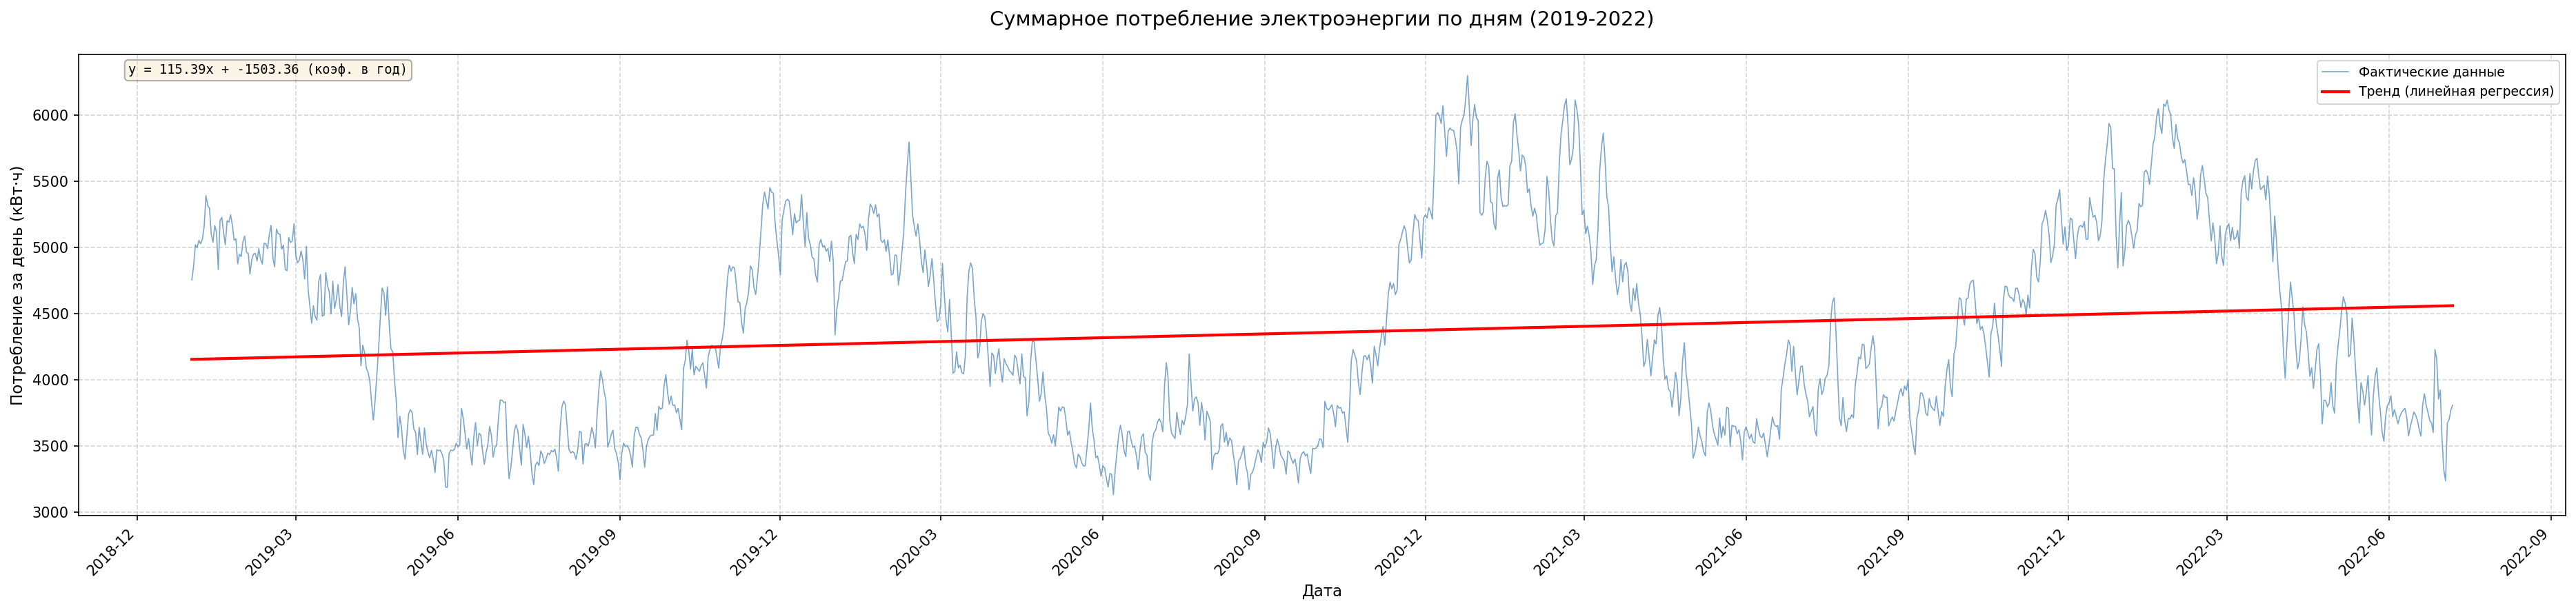

(<Figure size 3750x900 with 1 Axes>,
 <Axes: title={'center': 'Суммарное потребление электроэнергии по дням (2019-2022)'}, xlabel='Дата', ylabel='Потребление за день (кВт·ч)'>)

In [6]:
ChartByDay.plot_daily_consumption(
    daily_df, metric='total_consumption',
    title='\u0421\u0443\u043c\u043c\u0430\u0440\u043d\u043e\u0435 \u043f\u043e\u0442\u0440\u0435\u0431\u043b\u0435\u043d\u0438\u0435 \u044d\u043b\u0435\u043a\u0442\u0440\u043e\u044d\u043d\u0435\u0440\u0433\u0438\u0438 \u043f\u043e \u0434\u043d\u044f\u043c (2019-2022)',
    filename='../analysis_output/daily_total_consumption.png',
    add_regression=True, figsize_width=25)


✅ График сохранён: ../analysis_output/daily_avg_consumption.png


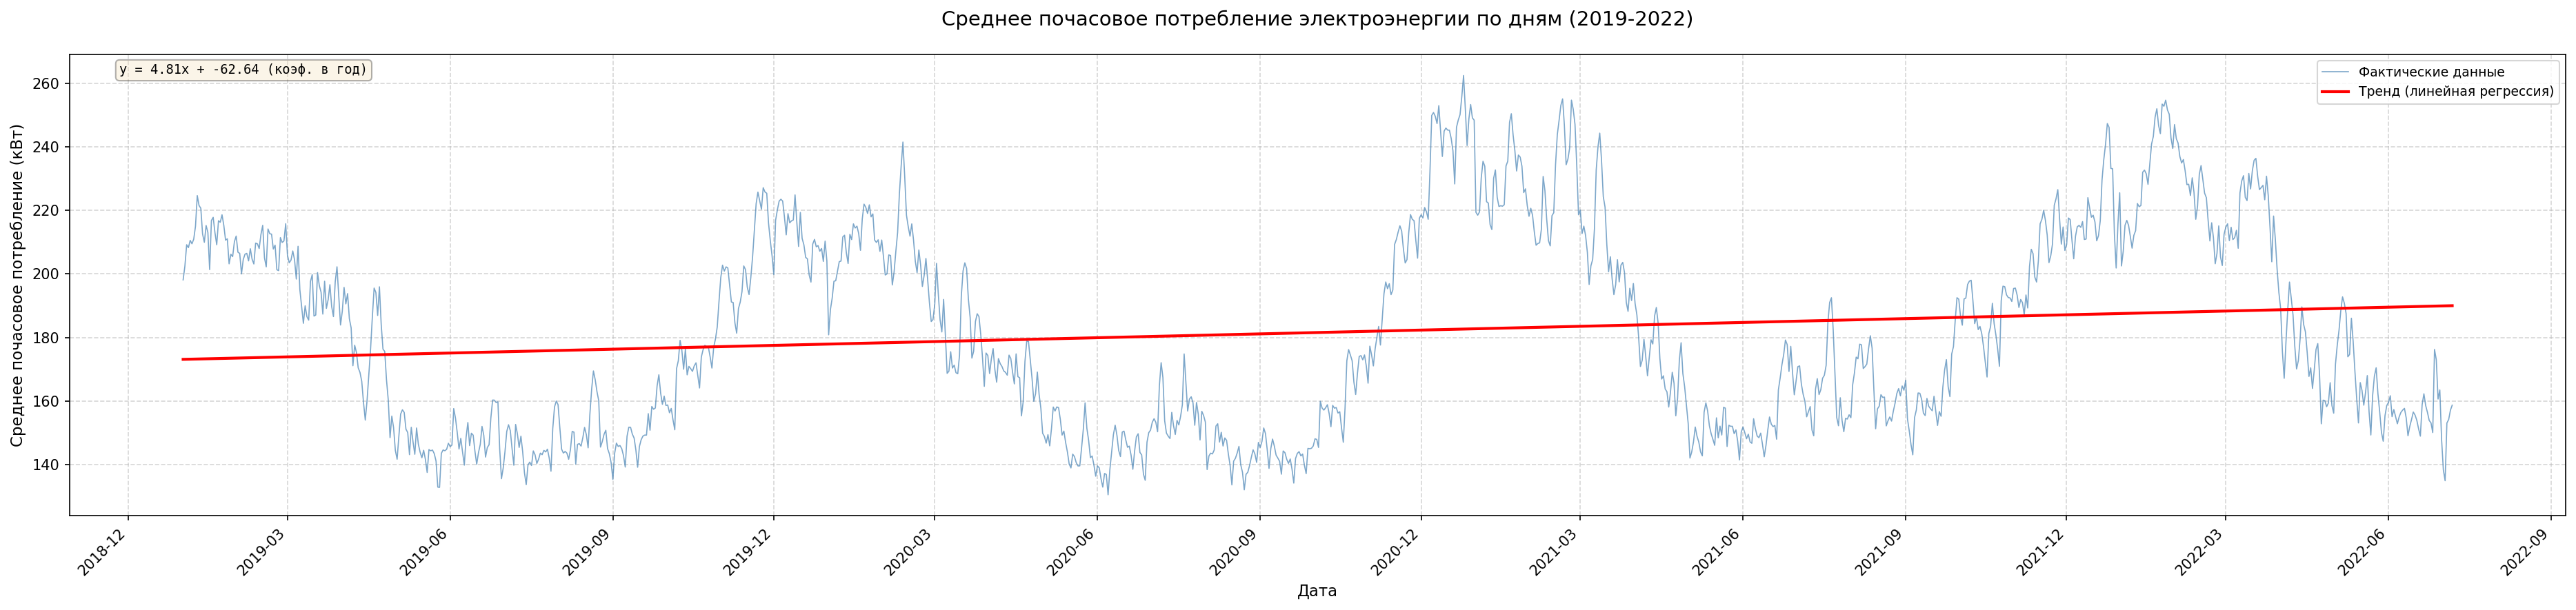

(<Figure size 3750x900 with 1 Axes>,
 <Axes: title={'center': 'Среднее почасовое потребление электроэнергии по дням (2019-2022)'}, xlabel='Дата', ylabel='Среднее почасовое потребление (кВт)'>)

In [7]:
ChartByDay.plot_daily_consumption(
    daily_df, metric='avg_consumption',
    title='\u0421\u0440\u0435\u0434\u043d\u0435\u0435 \u043f\u043e\u0447\u0430\u0441\u043e\u0432\u043e\u0435 \u043f\u043e\u0442\u0440\u0435\u0431\u043b\u0435\u043d\u0438\u0435 \u044d\u043b\u0435\u043a\u0442\u0440\u043e\u044d\u043d\u0435\u0440\u0433\u0438\u0438 \u043f\u043e \u0434\u043d\u044f\u043c (2019-2022)',
    filename='../analysis_output/daily_avg_consumption.png',
    add_regression=True, figsize_width=25)


## 6. Статистика по сезонам и годам

In [8]:
daily_complete = daily_df[daily_df['is_complete']].copy()
daily_complete['date_obj'] = pd.to_datetime(daily_complete['date_only'])
daily_complete['year'] = daily_complete['date_obj'].dt.year
daily_complete['month'] = daily_complete['date_obj'].dt.month
daily_complete['season'] = daily_complete['month'].map(
    {12:'\u0437\u0438\u043c\u0430', 1:'\u0437\u0438\u043c\u0430', 2:'\u0437\u0438\u043c\u0430',
     3:'\u0432\u0435\u0441\u043d\u0430', 4:'\u0432\u0435\u0441\u043d\u0430', 5:'\u0432\u0435\u0441\u043d\u0430',
     6:'\u043b\u0435\u0442\u043e', 7:'\u043b\u0435\u0442\u043e', 8:'\u043b\u0435\u0442\u043e',
     9:'\u043e\u0441\u0435\u043d\u044c', 10:'\u043e\u0441\u0435\u043d\u044c', 11:'\u043e\u0441\u0435\u043d\u044c'})

print("\U0001F50D \u0421\u0442\u0430\u0442\u0438\u0441\u0442\u0438\u043a\u0430 \u043f\u043e \u0441\u0435\u0437\u043e\u043d\u0430\u043c:")
seasonal_stats = daily_complete.groupby('season')['total_consumption'].agg(['mean', 'std', 'count'])
print(seasonal_stats.round(2))


🔍 Статистика по сезонам:
           mean     std  count
season                        
весна   4213.57  590.90    368
зима    5288.58  379.90    330
лето    3666.88  259.85    313
осень   4216.81  589.99    273


In [9]:
print("\U0001F4C5 \u0421\u0442\u0430\u0442\u0438\u0441\u0442\u0438\u043a\u0430 \u043f\u043e \u0433\u043e\u0434\u0430\u043c:")
yearly_stats = daily_complete.groupby('year')['total_consumption'].agg(['sum', 'mean', 'std', 'count'])
print(yearly_stats.round(2))


📅 Статистика по годам:
             sum     mean     std  count
year                                    
2019  1543529.98  4228.85  680.19    365
2020  1537863.99  4201.81  784.44    366
2021  1638857.02  4490.02  724.98    365
2022   874491.80  4651.55  793.90    188
